# MTN Churn Intelligence System
*Predictive Retention & Customer Insight for Telecom  Growth*
## Project Overview 
This project addresses a critical business challenge for **MTN Nigeria** as an increasing churning rate poses as an obstacle to business sustenance. This end-to-end system moves beyond static analysis to providing real-time prediction tool for identifying at-risk customers while focusing on the roll-out of 5G services and regional market pressures. 

### Business Goals
* Identification  of at-risk high-value customers before they switch to competitors.
* Identification of regional factors for churning
* Recommendation of a specific retention offer based on individual customer data usage and tenure.

### The Dataset
The project makes use of the **Kaggle's Q1 2025 MTN Nigeria Customer Churn Dataset** which includes 
* Service Metrics such as 5G router adoption, data plan types, average signal strength*
* Demographics such as Customer location, tenure and age group.
* Sentiment such as customer interaction logs and satisfaction score.

## Key Features
### 1. Exploratory Data Analysis

Comprehensive visuals were created using **Seaborn** and **Plotly** for revealing:
* Churn by Geography: Heatmap showing high-churn hotspots.
* Feature Correlation: showing customer loyalty
* Sentiment Analysis: For insights into customer review.

### 2. Predictive Modeling

An optimized XGBoost classifier for identifying churn patterns using:
* Metrics such as Recall and F1-Score to ensure not missing-out of at-risk customers.
* SHAP Values for the expalnation of why the model predicted a specific customer would churn

### 3. Automated Alerting System

A Python-based workflow is created for filtering high-value customers and the triggering of an automated alert when a satisfaction score drops below a specific threshold. 

### 4. Live Deployment 

A web-based dashboard is created for stakeholders for the:
* Computation of customer stats and performing some toogling based on tenure, data usage and complaints.
* Generation of real-time churn risk percentage for the recommendation of "Retention Action".

## Tech Stack
* Language: SQL and Python
* Libraries: Pandas, Sckitlearn, Matplotlib and Streamlit
* Deployment: Streamlit Cloud and Github

## Task One Dataset Loading and Library Importation 
for the performance of data operations

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score,f1_score
import warnings
warnings.filterwarnings("ignore")
#Loading of the dataset
df = pd.read_csv("Kaggle_MTN_Churn_data.csv")
df.head(10)# for the display of the first five rows

,Customer ID,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
0,CUST0001,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation
1,CUST0002,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors
2,CUST0003,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,NaN
3,CUST0003,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,NaN
4,CUST0003,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,NaN
5,CUST0004,Mar-25,36,Gombe,4G Router,Female,1,Poor,14,10GB+10mins Monthly Plan,4500,9,40500,92.72,No,NaN
6,CUST0005,Jan-25,57,Oyo,4G Router,Male,3,Good,53,25GB Monthly Plan,9000,16,144000,42.92,No,NaN
7,CUST0006,Feb-25,74,Plateau,Mobile SIM Card,Female,5,Excellent,9,7GB Monthly Plan,3500,5,17500,44.25,No,NaN
8,CUST0006,Feb-25,74,Plateau,5G Broadband Router,Female,5,Excellent,9,1.5TB Yearly Broadband Plan,150000,2,300000,18.64,No,NaN
9,CUST0006,Feb-25,74,Plateau,4G Router,Female,5,Excellent,9,65GB Monthly Plan,16000,6,96000,30.99,No,NaN


## Task Two: Data Preprocessing
This is for ensuring the dataset is in machine-friendly format, 
* Through the filling of empty cells

In [37]:
df.isnull().sum()
#Replacing the Nan values within "Reasons for Churn" with "Active User"
df["Reasons for Churn"] = df["Reasons for Churn"].fillna("Active User")
df.head()

,Customer ID,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,...,Customer Churn Status,Reasons for Churn,ARPU,ATV,Data Efficiency,Purchase Frequency,Customer_Vintage,Satisfaction Score,Age Group,Geopolitical Zone
0,CUST0001,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,...,Yes,Relocation,332500.000000,35000.0,0.000067,9.500000,New,0.4,Millennial,North Central
1,CUST0002,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,...,Yes,Better Offers from Competitors,3000.000000,5500.0,0.000300,0.545455,Established,0.4,Gen-Z,North Central
2,CUST0003,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,...,No,Active User,2666.666667,20000.0,0.000060,0.133333,Loyal,0.2,Gen-Z,North West
3,CUST0003,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,...,No,Active User,66.666667,500.0,0.049263,0.133333,Loyal,0.2,Gen-Z,North West
4,CUST0003,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,...,No,Active User,2250.000000,9000.0,0.000565,0.250000,Loyal,0.2,Gen-Z,North West


## Task Three: Exploratory Data Analysis
The focus of this analysis include:
* Identification of the average person that leaves MTN
* Plotting visuals for indicators of customers that will churn
* Calculation of risks that comes with the loss of customers

A total of 284 churned, making it a loss of over 29% of her total customers


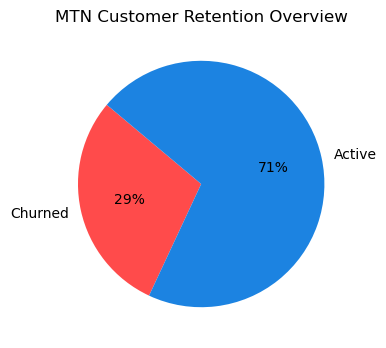

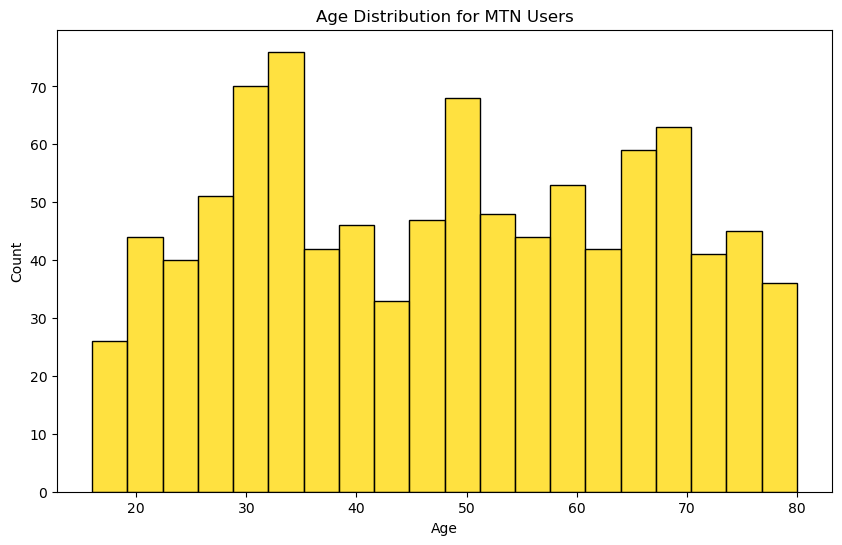

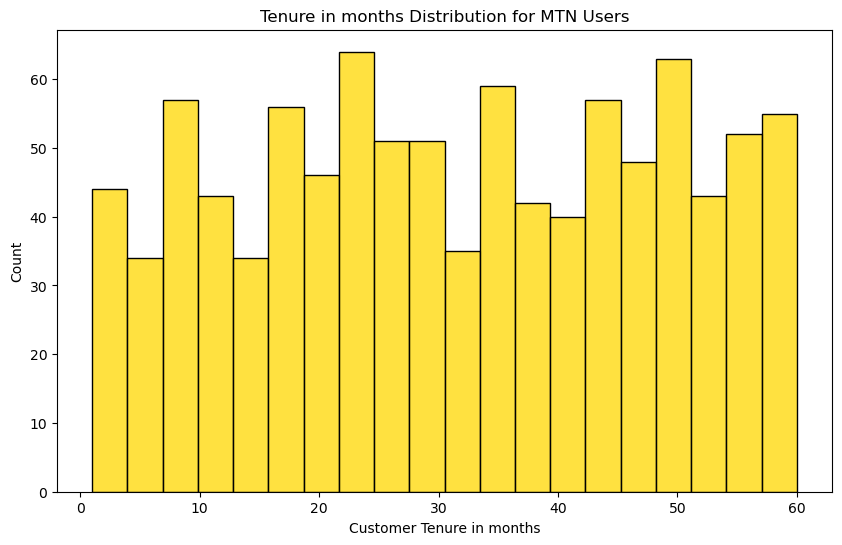

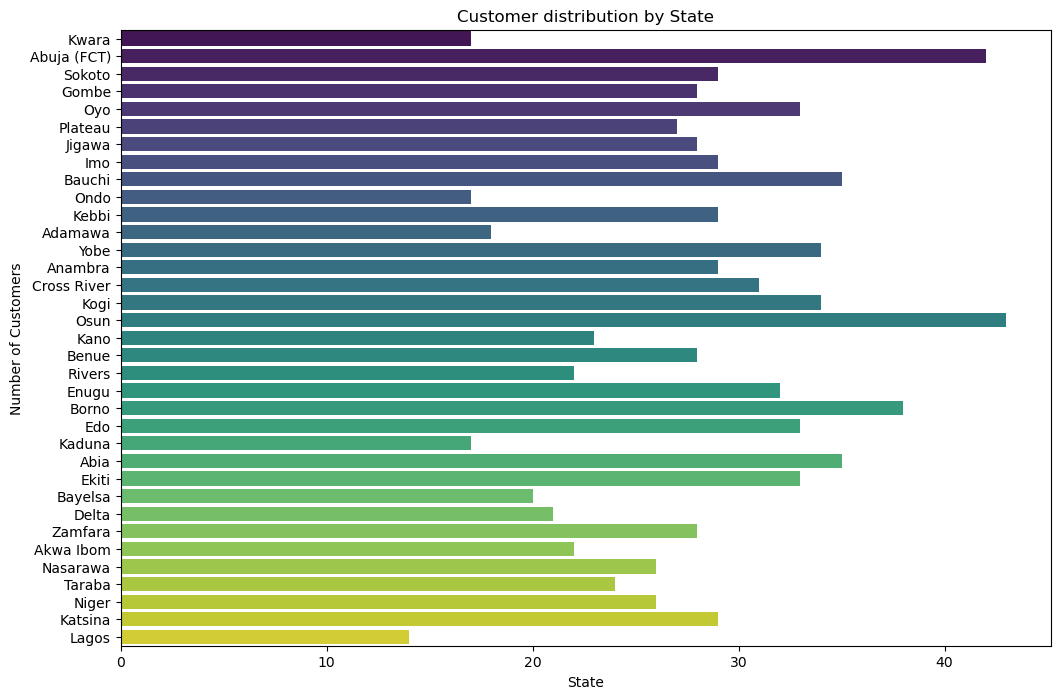

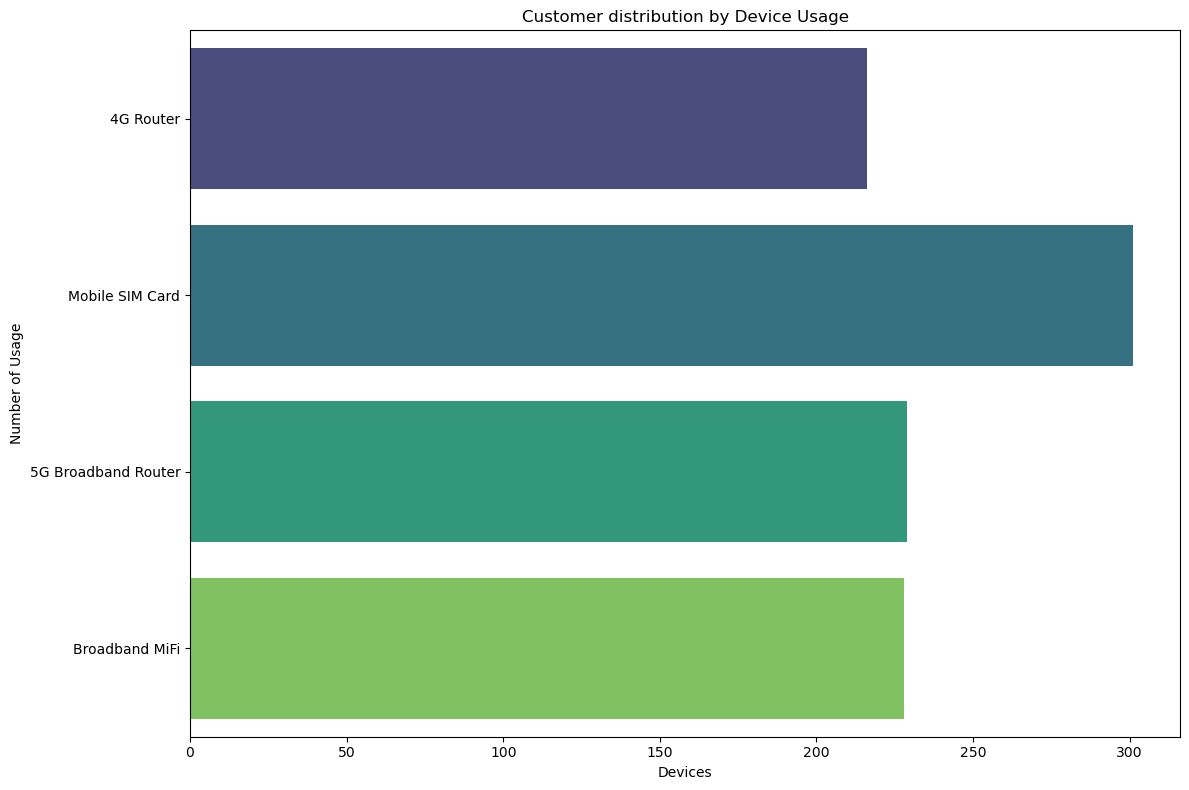

In [25]:
import matplotlib.dates as mdates
# Calculation of overall churn rate and its percentage
total_customers = len(df)
churn_count = df[df["Customer Churn Status"] == "Yes"].shape[0]
churn_percentage = (churn_count/total_customers) * 100
print(f"A total of {churn_count} churned, making it a loss of over {churn_percentage:.0f}% of her total customers")

#Visualizing this finding
plt.figure(figsize=(6,4))
plt.pie([churn_count,total_customers - churn_count],
       labels = ["Churned","Active"],
       autopct = "%1.0f%%",
       startangle = 140,
       colors = ["#FF4B4B", "#1C83E1"])
plt.title("MTN Customer Retention Overview")

plt.figure(figsize=(10,6))
sns.histplot(df["Age"], bins=20, color="gold")
plt.title("Age Distribution for MTN Users")

plt.figure(figsize=(10,6))
sns.histplot(df["Customer Tenure in months"], bins=20, color="gold")
plt.title("Tenure in months Distribution for MTN Users")

plt.figure(figsize=(12,8))
sns.countplot(df["State"],palette="viridis")
plt.title("Customer distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.figure(figsize=(12,8))
sns.countplot(df["MTN Device"],palette="viridis")
plt.title("Customer distribution by Device Usage")
plt.xlabel("Devices")
plt.ylabel("Number of Usage")

plt.tight_layout()
plt.show()

<Figure size 1000x1500 with 0 Axes>

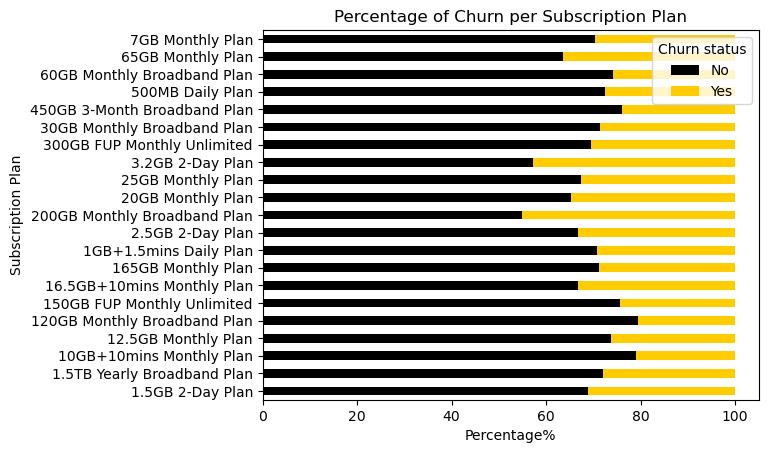

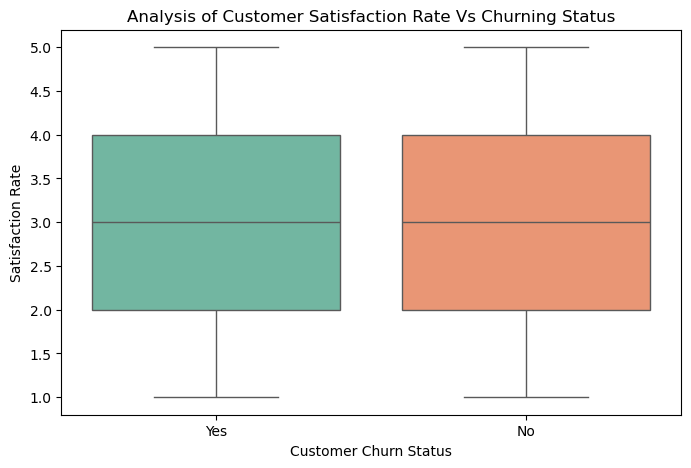

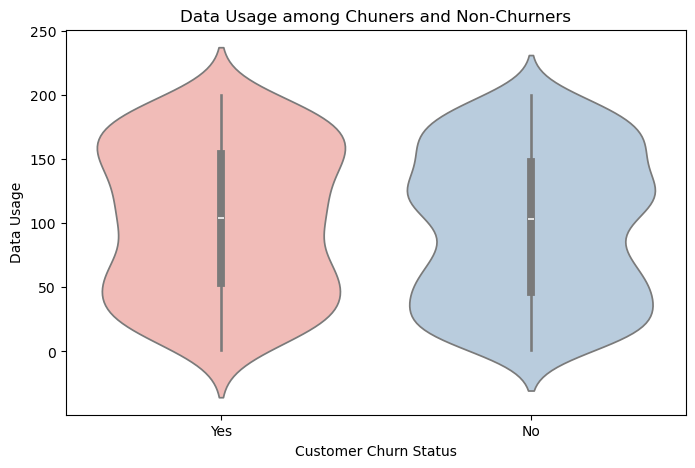

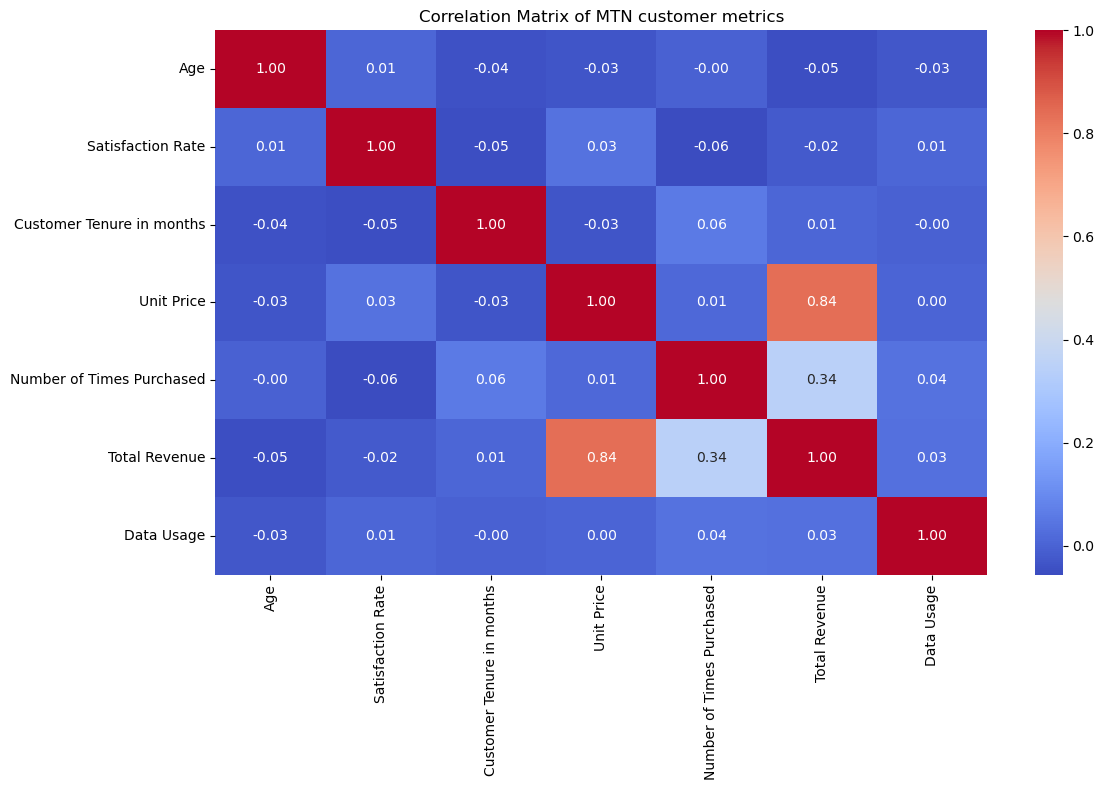

In [26]:
#For Bivariate Analysis: Attention are faced towards identifying features that directly factors Churning
#Plotting Churn by Subscription plan 
plt.figure(figsize=(10,15))
prop_df= pd.crosstab(df["Subscription Plan"], df["Customer Churn Status"], normalize="index")*100
prop_df.plot(kind="barh", stacked=True,color=["#000000","#FFCC00"])
plt.title("Percentage of Churn per Subscription Plan")
plt.xlabel("Percentage%")
plt.legend(title="Churn status")

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Customer Churn Status", y="Satisfaction Rate", palette="Set2")
plt.title("Analysis of Customer Satisfaction Rate Vs Churning Status")

plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="Customer Churn Status", y="Data Usage", palette="Pastel1")
plt.title("Data Usage among Chuners and Non-Churners")

numerical_cols = df.select_dtypes(include=["float64","int64"]).columns
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of MTN customer metrics")
plt.tight_layout()
plt.show()

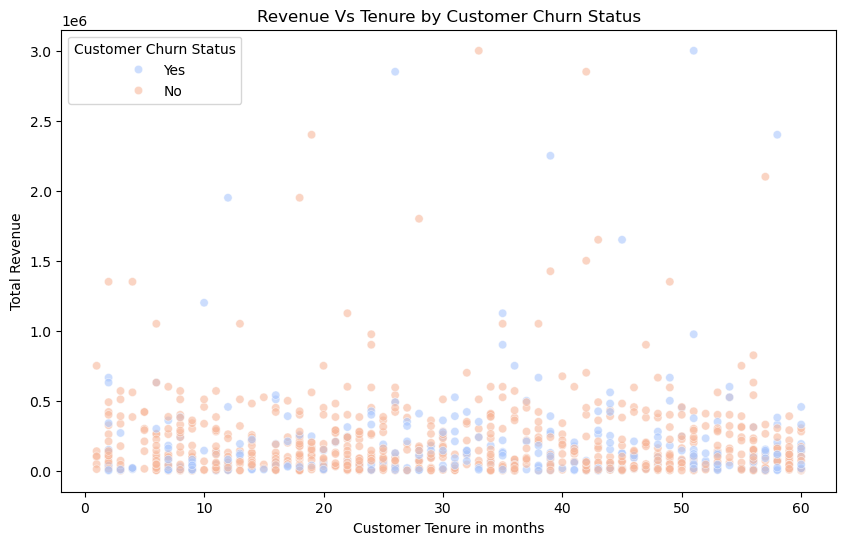

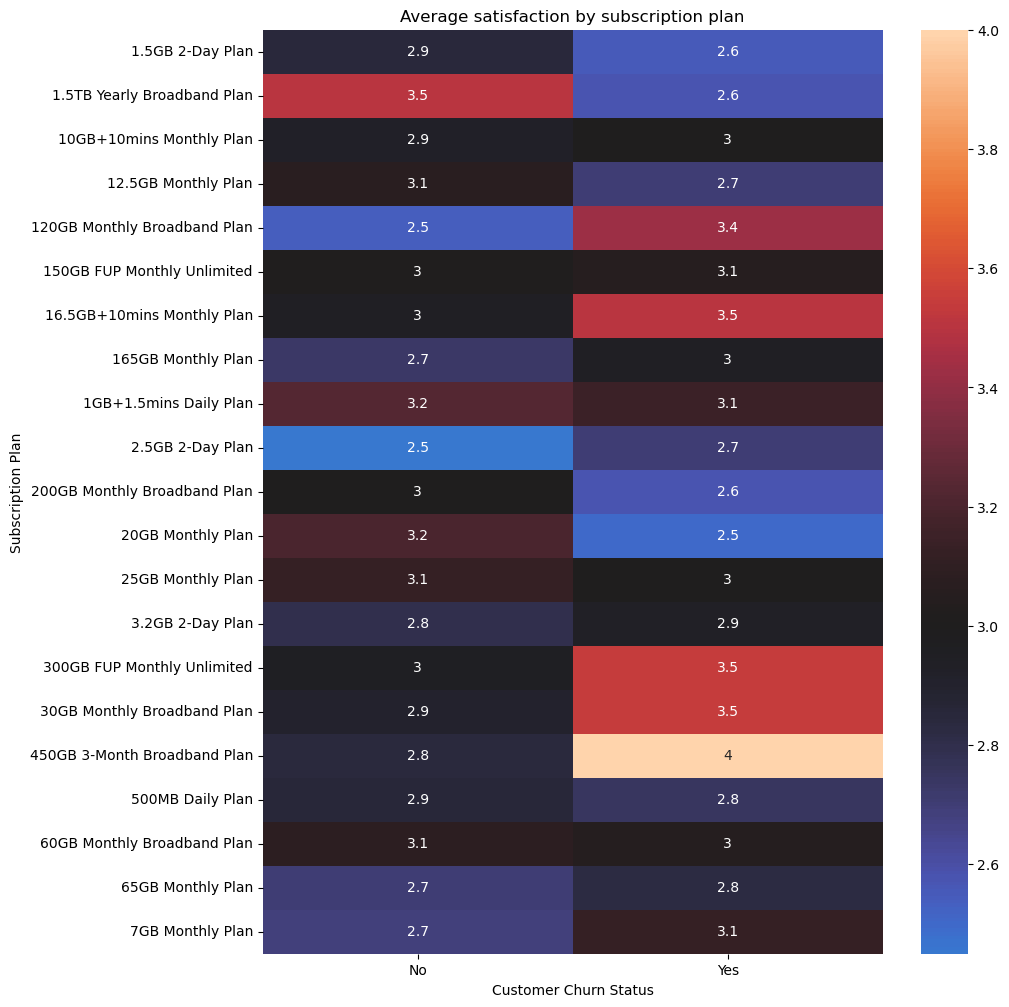

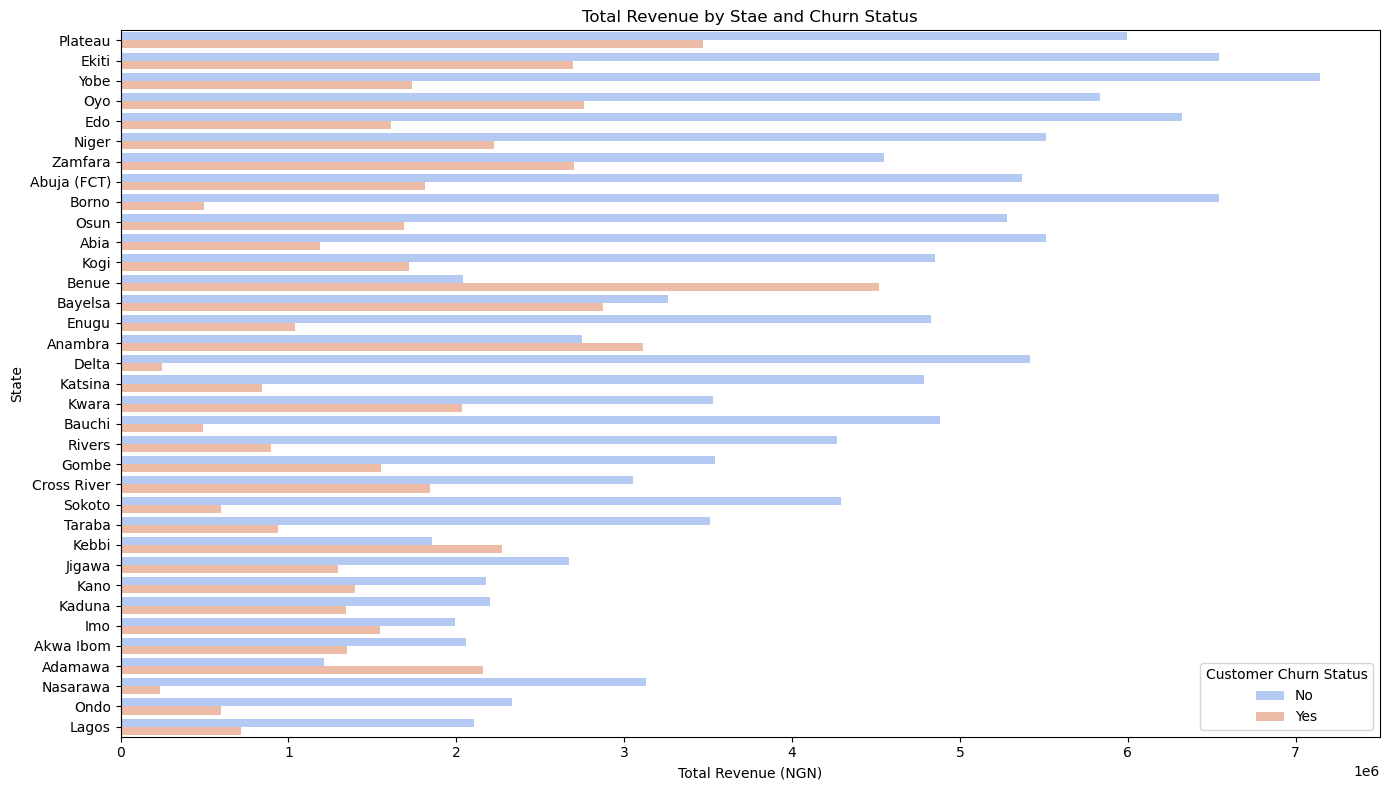

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Customer Tenure in months", y="Total Revenue",hue="Customer Churn Status",palette="coolwarm", alpha=0.6)
plt.title("Revenue Vs Tenure by Customer Churn Status")

plt.figure(figsize=(10,12))
pivot_df = df.pivot_table(index="Subscription Plan",columns="Customer Churn Status",values="Satisfaction Rate",aggfunc="mean")
sns.heatmap(pivot_df, annot=True,center=3)
pivot_df.style.background_gradient(cmap=plt.cm.coolwarm, axis=None)
plt.title("Average satisfaction by subscription plan")

state_revenue = df.groupby(["State", "Customer Churn Status"])["Total Revenue"].sum().reset_index()
state_order = state_revenue.groupby("State")["Total Revenue"].sum().sort_values(ascending=False).index
plt.figure(figsize=(14,8))
sns.barplot(data=state_revenue, y="State",x="Total Revenue", hue="Customer Churn Status", order=state_order, palette="coolwarm")
plt.title("Total Revenue by Stae and Churn Status")
plt.xlabel("Total Revenue (NGN)")

plt.tight_layout()
plt.show()

## Task Four: Feature Engineering
The dataset is a mix of demographic, financial and behavioural data, for an improved model performance there is need to move beyond raw data and create features that capture customer behavior over time. 

### 1. Financial & Usage Efficency 
* Average Revenue Per User (ARPU):"Total Revenue" / "Customer Tenure in months". To show the highest-value long-term customers.
* Average Transaction Value: "Total Revenue" / "Number of Times Purchased". For distinguish between customers who make many small purchases vs. one-time big spenders.
* Data Efficiency: "Data Usage" / "Total Revenue". To identification customers that pays more but yet uses very little data
### 2. Time-Based Features
* Purchase Frequency: "Number of Times Purchased" / "Customer Tenure in months". Identify long-tenured customer with low purchase frequency.
* Customer Vintage: For the grouping of customers based on tenure. As Churning behavior varies among new and old customers.
### 3. Sentiment & Engagement
* Satisfaction Gap: creation of High-Risk/High-Value, as users with high subscription plan but give a low satisfaction Rate.
### 4. Demographic Grouping
* Age binning: create age categories by converting raw age to catch trends.(Gen-Z, Millennals,Gen-X)
* Geopolitical Zones: Group "State" column into Nigeria's 6 geopolitical zones to reveal if churn is tied to regional network issues.

In [29]:
#1.
df["ARPU"] = df["Total Revenue"] / df["Customer Tenure in months"].replace(0,1)
df["ATV"] = df["Total Revenue"] / df["Number of Times Purchased"].replace(0,1)
df["Data Efficiency"] = df["Data Usage"] /df["Total Revenue"].replace(0,1)

#2.
df["Purchase Frequency"] = df["Number of Times Purchased"]/df["Customer Tenure in months"].replace(0,1)
bins_tenure = [0, 6, 24, df["Customer Tenure in months"].max()]
labels_tenure = ["New", "Established","Loyal"]
df["Customer_Vintage"] = pd.cut(df["Customer Tenure in months"], bins= bins_tenure, labels=labels_tenure)

#3.
df["Satisfaction Score"] = df["Satisfaction Rate"] / 5

#4.
bins_age = [0, 25, 40, 60, 100]
labels_age = ["Gen-Z", "Millennial", "Gen-X", "Senior"]
df["Age Group"] = pd.cut(df["Age"], bins=bins_age, labels=labels_age)
zone_map = {
    'Lagos': 'South West', 'Oyo': 'South West', 'Ogun': 'South West', 'Ondo': 'South West', 'Osun': 'South West', 'Ekiti': 'South West',
    'Abia': 'South East', 'Anambra': 'South East', 'Ebonyi': 'South East', 'Enugu': 'South East', 'Imo': 'South East',
    'Rivers': 'South South', 'Akwa Ibom': 'South South', 'Bayelsa': 'South South', 'Cross River': 'South South', 'Delta': 'South South', 'Edo': 'South South',
    'Kano': 'North West', 'Kaduna': 'North West', 'Katsina': 'North West', 'Kebbi': 'North West', 'Jigawa': 'North West', 'Sokoto': 'North West', 'Zamfara': 'North West',
    'Bauchi': 'North East', 'Borno': 'North East', 'Gombe': 'North East', 'Taraba': 'North East', 'Yobe': 'North East', 'Adamawa': 'North East',
    'Kwara': 'North Central', 'Kogi': 'North Central', 'Plateau': 'North Central', 'Nasarawa': 'North Central', 'Benue': 'North Central', 'Niger': 'North Central', 'Abuja (FCT)': 'North Central'
}
df['Geopolitical Zone'] = df['State'].map(zone_map)
df.head(10)

,Customer ID,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,...,Customer Churn Status,Reasons for Churn,ARPU,ATV,Data Efficiency,Purchase Frequency,Customer_Vintage,Satisfaction Score,Age Group,Geopolitical Zone
0,CUST0001,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,...,Yes,Relocation,332500.000000,35000.0,0.000067,9.500000,New,0.4,Millennial,North Central
1,CUST0002,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,...,Yes,Better Offers from Competitors,3000.000000,5500.0,0.000300,0.545455,Established,0.4,Gen-Z,North Central
2,CUST0003,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,...,No,Active User,2666.666667,20000.0,0.000060,0.133333,Loyal,0.2,Gen-Z,North West
3,CUST0003,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,...,No,Active User,66.666667,500.0,0.049263,0.133333,Loyal,0.2,Gen-Z,North West
4,CUST0003,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,...,No,Active User,2250.000000,9000.0,0.000565,0.250000,Loyal,0.2,Gen-Z,North West
5,CUST0004,Mar-25,36,Gombe,4G Router,Female,1,Poor,14,10GB+10mins Monthly Plan,...,No,Active User,2892.857143,4500.0,0.002289,0.642857,Established,0.2,Millennial,North East
6,CUST0005,Jan-25,57,Oyo,4G Router,Male,3,Good,53,25GB Monthly Plan,...,No,Active User,2716.981132,9000.0,0.000298,0.301887,Loyal,0.6,Gen-X,South West
7,CUST0006,Feb-25,74,Plateau,Mobile SIM Card,Female,5,Excellent,9,7GB Monthly Plan,...,No,Active User,1944.444444,3500.0,0.002529,0.555556,Established,1.0,Senior,North Central
8,CUST0006,Feb-25,74,Plateau,5G Broadband Router,Female,5,Excellent,9,1.5TB Yearly Broadband Plan,...,No,Active User,33333.333333,150000.0,0.000062,0.222222,Established,1.0,Senior,North Central
9,CUST0006,Feb-25,74,Plateau,4G Router,Female,5,Excellent,9,65GB Monthly Plan,...,No,Active User,10666.666667,16000.0,0.000323,0.666667,Established,1.0,Senior,North Central


## Task Five: Train, Test and Split

In [39]:
#Dropping Columns with IDs that provide the model with useful information
df1 = df.drop(["Customer ID", "Customer Review","Reasons for Churn","Satisfaction Rate",
               "State","Age Group","Subscription Plan"],axis=1)

#Encoding the target Column which is Customer Churn Status
le = LabelEncoder()
df1["Customer Churn Status"] = le.fit_transform(df1["Customer Churn Status"])

#Identifying columns for OneHot Encoding and Standard Scaling
categorical_cols = ["MTN Device","Gender","Geopolitical Zone","Customer_Vintage"]
numerical_cols =["Age", "Customer Tenure in months","Unit Price","Number of Times Purchased","Total Revenue",
                "Data Usage","ARPU","ATV","Data Efficiency","Purchase Frequency","Satisfaction Score"]
#One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
encoded_columns = ohe.fit_transform(df1[categorical_cols])
encoded_df = pd.DataFrame(encoded_columns, columns=ohe.get_feature_names_out(categorical_cols))

#Standard Scaler
scaler = StandardScaler()
scaled_columns = scaler.fit_transform(df1[numerical_cols])
scaled_df = pd.DataFrame(scaled_columns,columns=numerical_cols)

#Merging Scaled Numbers, Encoded Features and Target Column together for training
X = pd.concat([scaled_df,encoded_df], axis=1)
y = df1["Customer Churn Status"]
print(f"Model Ready For Training! Total Features:{X.shape[1]}")
print(X.columns.tolist())

#Feature Splitting as 80% is for training and 20% is for testing
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

#Checking Churning Distribution in the set
print(y_train.value_counts(normalize=True))

Model Ready For Training! Total Features:22
['Age', 'Customer Tenure in months', 'Unit Price', 'Number of Times Purchased', 'Total Revenue', 'Data Usage', 'ARPU', 'ATV', 'Data Efficiency', 'Purchase Frequency', 'Satisfaction Score', 'MTN Device_5G Broadband Router', 'MTN Device_Broadband MiFi', 'MTN Device_Mobile SIM Card', 'Gender_Male', 'Geopolitical Zone_North East', 'Geopolitical Zone_North West', 'Geopolitical Zone_South East', 'Geopolitical Zone_South South', 'Geopolitical Zone_South West', 'Customer_Vintage_Loyal', 'Customer_Vintage_New']
Training set size: 779
Testing set size: 195
Customer Churn Status
0    0.708601
1    0.291399
Name: proportion, dtype: float64


## Task Six: Model Selection and Building
The choice model for this project covers three main philosophies of classification, which includes Linearity, Geometric and Tree-based modeling. Overfitting in machine learning occurs when a model performed well at learning noise/random patterns in the training data and cannot generalize to new or unseen data. Signs of overfitting includes model accuracy score on training data to be at 99% but 70% on test data.
### The choice models for this project and their reasons are:
* Logistic Regression: To act as the baseline model as it is faster and higly interpretable
* Support Vector Machine: For helping to find the boundaries between churners and non-churners in high dimensional space.
* Random Forest: For tackling overfitting and handling the mix of categorical and numerical data, as they create many decision trees and average them
* XGBoost: It is the state of the art model for tabular churn data as it creates decision trees squentially and with each new tree correcting the errors of the previous one

---Logistic Regression---
              precision    recall  f1-score   support

           0       0.77      0.46      0.57       138
           1       0.34      0.67      0.45        57

    accuracy                           0.52       195
   macro avg       0.55      0.56      0.51       195
weighted avg       0.64      0.52      0.54       195

--------------------
---SVM---
              precision    recall  f1-score   support

           0       0.80      0.49      0.61       138
           1       0.36      0.70      0.48        57

    accuracy                           0.55       195
   macro avg       0.58      0.60      0.54       195
weighted avg       0.67      0.55      0.57       195

--------------------
---Random Forest---
              precision    recall  f1-score   support

           0       0.71      0.96      0.82       138
           1       0.38      0.05      0.09        57

    accuracy                           0.70       195
   macro avg       0.54      0

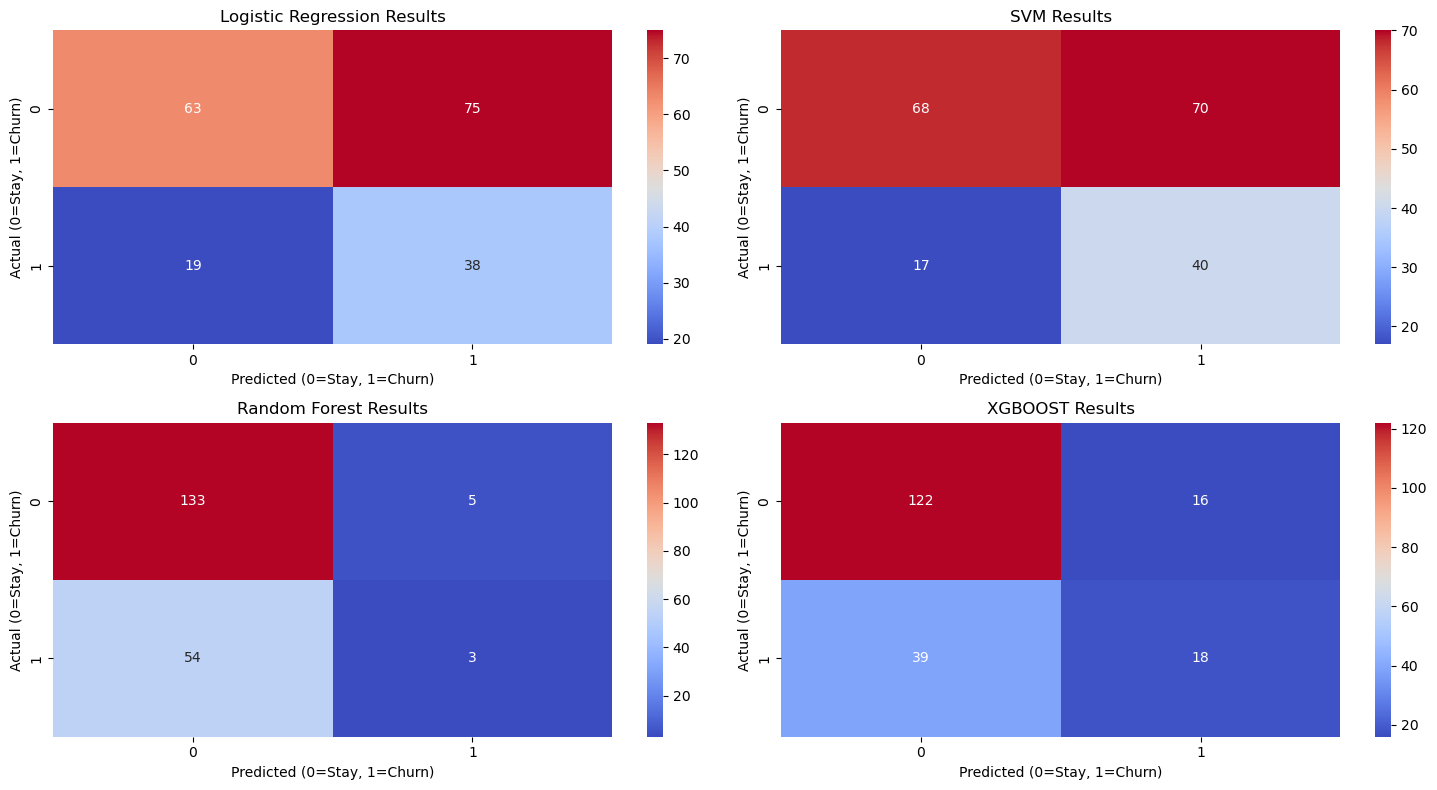

In [41]:
#initializing the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight={0:1, 1:3}),
    "SVM":SVC(probability=True, class_weight={0:1, 1:3}),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0:1, 1:3}),
    "XGBOOST": XGBClassifier(use_label_encoder=False,eval_metric="logloss",class_weight={0:1, 1:3})
}

#Looping through all the models
results = {}
for name, model in models.items():
    #Training
    model.fit(X_train, y_train)
    
    #Predicting
    y_pred = model.predict(X_test)

    #Evaluating
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {"Accuracy":acc,"F1-Score": f1}

    print(f"---{name}---")
    print(classification_report(y_test,y_pred))
    print("-"*20)

summary_df = pd.DataFrame(results).T
print("\n--- Model Summary---")
print(summary_df.sort_values(by="F1-Score", ascending=False))

#Plotting the Confusion matrix for the 4 models
fig, axes = plt.subplots(2,2, figsize=(15,8))
axes = axes.flatten()

for i, (name,model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm,annot=True,fmt="d", cmap="coolwarm", ax=axes[i],cbar=True)
    axes[i].set_title(f"{name} Results")
    axes[i].set_xlabel("Predicted (0=Stay, 1=Churn)")
    axes[i].set_ylabel("Actual (0=Stay, 1=Churn)")

plt.tight_layout()
plt.show()

In [43]:
from imblearn.over_sampling import SMOTE

#initializing SMOTE
smote = SMOTE(random_state=42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)
print(f"Resampling training data:{y_train_res.value_counts().to_dict()}")

Resampling training data:{0: 552, 1: 552}


In [45]:
#initializing the models
balanced_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM":SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBOOST": XGBClassifier(use_label_encoder=False,eval_metric="logloss")
}

#Looping through all the models
results_balanced = {}
threshold = 0.40
for name, model in models.items():
    #Training
    model.fit(X_train_res, y_train_res)
    
    #Predicting
    y_probs = model.predict_proba(X_test)[:,1]
    y_pred_custom = (y_probs >= threshold).astype(int)

    #Evaluating
    acc = accuracy_score(y_test,y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results_balanced[name] = {"F1-Score":f1_score(y_test,y_pred_custom),
                             "Accuracy": acc}

    print(f"---{name}---")
    print(classification_report(y_test,y_pred_custom))
    print("-"*20)

summary_df = pd.DataFrame(results_balanced).T
print("\n--- Model Summary For Threshold 0.40---")
print(summary_df.sort_values(by="F1-Score", ascending=False))

---Logistic Regression---
              precision    recall  f1-score   support

           0       1.00      0.01      0.03       138
           1       0.30      1.00      0.46        57

    accuracy                           0.30       195
   macro avg       0.65      0.51      0.24       195
weighted avg       0.79      0.30      0.15       195

--------------------
---SVM---
              precision    recall  f1-score   support

           0       0.74      0.63      0.68       138
           1       0.35      0.47      0.40        57

    accuracy                           0.58       195
   macro avg       0.54      0.55      0.54       195
weighted avg       0.63      0.58      0.60       195

--------------------
---Random Forest---
              precision    recall  f1-score   support

           0       0.74      0.66      0.70       138
           1       0.35      0.44      0.39        57

    accuracy                           0.59       195
   macro avg       0.54      0

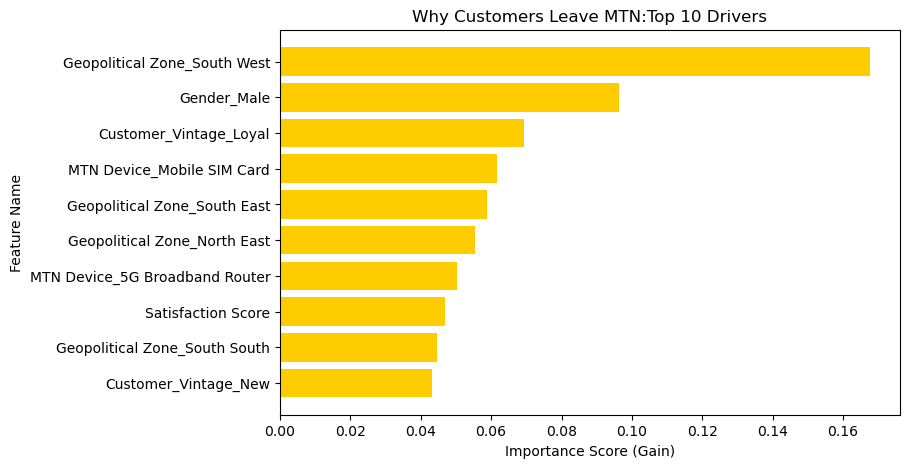

In [47]:
#XGBoost was able to catch the churners without desrotying the overall accuracy making it a production-ready mosel and intelligent model in finding complex pattern 
# with Feature importance plotting this model can be transformed from a"Black Box Ai" into a strategic Map for MTN's Leadership.

best_xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
best_xgb.fit(X_train_res,y_train_res)
#2. Extracting the importance and pairing it with their names
importances = best_xgb.feature_importances_
feature_names = X_train.columns
#3.  Creating the DataFrame for easier plotting
feat_imp_df = pd.DataFrame({"Importance":importances},index=feature_names)
feat_imp_df = feat_imp_df.sort_values(by="Importance",ascending=False).head(10)

#4. Plotting the Top 10 Features
plt.figure(figsize=(8,5))
plt.barh(feat_imp_df.index,feat_imp_df["Importance"],color="#FFCC00")
plt.gca().invert_yaxis()
plt.title("Why Customers Leave MTN:Top 10 Drivers")
plt.xlabel("Importance Score (Gain)")
plt.ylabel("Feature Name")
plt.show()

## Task Seven: Hyperparameter Tuning
GridSearchCV is used to squeeze more performance out of the XGBoost model

In [49]:
from sklearn.model_selection import GridSearchCV

#1. Defining the parameters to test
param_grid = {
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2],
    "n_estimators":[100,200],
    "subsample":[0.8,10]
}

#2. Initializing GridSearchCV
grid_search = GridSearchCV(
    estimator = XGBClassifier(eval_metric = "logloss"),
    param_grid = param_grid,
    scoring = "f1",# this is for optmizing f1-score
    cv = 3,
    verbose = 1
)

#3. Fitting the modek
grid_search.fit(X_train_res,y_train_res)
print("Best Parameters:",grid_search.best_params_)
final_model = grid_search.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


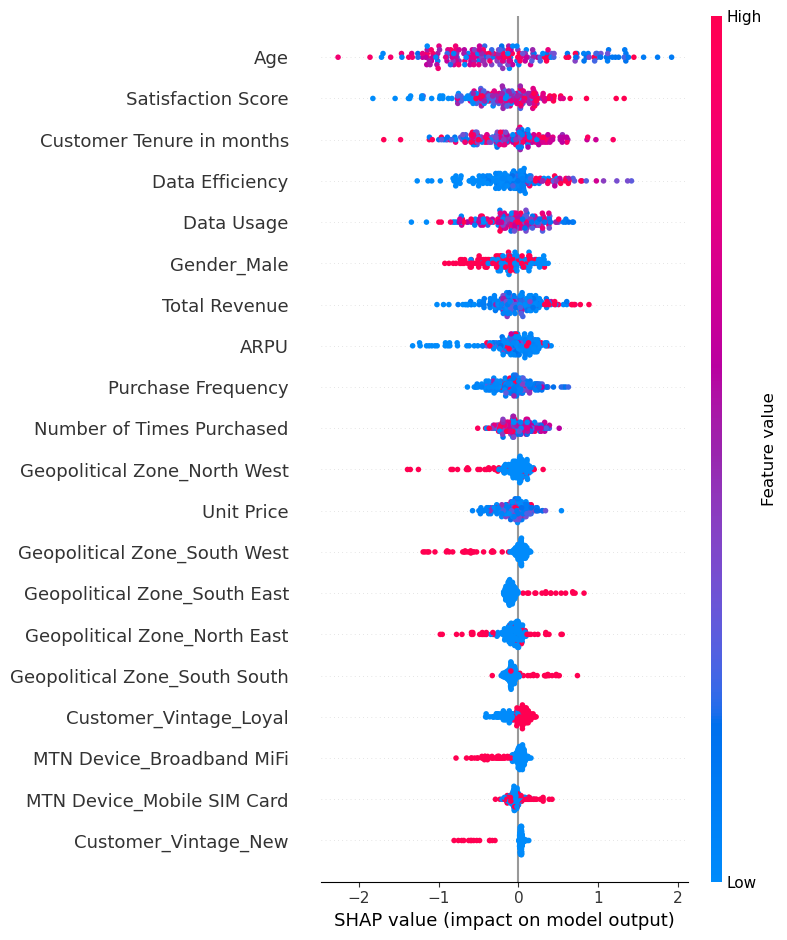

<Figure size 640x480 with 0 Axes>

In [51]:
import shap

#1. Initializing the Shap explainer with your final Xgboost
explainer = shap.TreeExplainer(final_model)

#2. Calculate SHAP values for your test set
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(12,8))
#3. creating summary plot
shap.summary_plot(shap_values, X_test)

plt.tight_layout()
plt.show()

## Task Eight: Streamlit Deployment
This allows managers better view of why customers are likely to leave

In [ ]:
import joblib #for loading saved model

#Saving the model
joblib.dump(final_model,"MTN_Churn_Model.pkl")

#Save feature list
joblib.dump(X_train_res.columns.tolist(),"feature_list.pkl")

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
#Load model and features
model = joblib.load("MTN_Churn_Model.pkl")
features = joblib.load("feature_list.pkl")

st.set_page_config(page_title="MTN Churn Predictor")
st.title("MTN Churn Prediction Dashboard")
st.markdown("Enter customer details here")

#Sidebar for User inputs
st.sidebar.header("Customer Profile")
age =st.sidebar.slider("Age",18,90,30)
revenue = st.sidebar.number_input("Total Revenue (\u20A6)",0,1000000,50000)
tenure = st.sidebar.number_input("Customer Tenure in months",0,120,24)
gender = st.sidebar.selectbox("Gender",["Male","Female"])
satisfaction = st.sidebar.slider("Satisfaction Score", 1,5,3)
zone = st.sidebar.selectbox("Geopolitical Zone",["South West","South East","North Central","North West","North East","South South"])
device = st.sidebar.selectbox("Device Type",["Mobile SIM Card","Broadband MiFi","5G Router"])

if st.button("Predict"):
    input_data = {
        "Age":age,
        "Customer Tenure in months":tenure,
        "Total Revenue":revenue,
        "Satisfaction Score":satisfaction,
        f"Geopolitical Zone_{zone}":1,
        f"Gender_{gender}":1
    }
    
    input_df = pd.DataFrame(0, index=[0], columns=features)

    for col,val in input_data.items():
        if col in features:
            input_df[col] = val
    
    if f"Geopolitical Zone_{zone}" in features:
        input_df[f"Geopolitical Zone_{zone}"] = 1
    if f"Gender_{gender}"in features:
        input_df[f"Gender_{gender}"] = 1
    if f"MTN Device_{device}" in features:
        input_df[f"MTN Device_{device}"] = 1

    input_df = input_df.reindex(columns=features, fill_value=0)

    risk_prob = model.predict_proba(input_df)[0,1]
    # display results
    st.subheader("Analysis Results")
    
    col1,col2 = st.columns(2)
    with col1:
        st.metric("Churn Probability",f"{risk_prob:.1%}")

    with col2:
        revenue_at_risk = risk_prob * revenue
        st.metric("Revenue at Risk",f"\u20A6{revenue_at_risk:,.2f}")
        
    if risk_prob > 0.40:
        st.error(f"High Risk: This customer is {risk_prob:.1%} likely to leave.")
        st.info("**Recommendation:** Offer 10GB Loyalty Data Bundle + 10% Discount on the next MiFi upgrade.")
    else:
        st.success(f"Low Risk: This customer is {risk_prob:.1%} likely to stay.")

st.info("Built for the MTN Churn Intelligence Portfolio Project")

## Task Nine: Business Intelligence Recommendation
The XGBoost modeling and SHAP result is telling us that:
* 1. The South West is the strongest driver for retention and the service standard here are blueprint for other regions
  2. Age is a strong predictor as younger customers are more likely to leave and so there is need for a youth-centric data bundles or social media driven loyalty rewards.
  3. Long-term "Loyal" vintage customers have shown higher churn than new ones. this suggests older customers feel neglected compared to new sign-ups.
  4. Customers using Broadband MiFi devices are more stable than SIM users and so there is need to incentivize SIM users in high-risk zones to help upgrade to MiFi or 5G routers.

In [ ]:
%pwd